# 📘 Session 18: Model Evaluation Beyond Accuracy
### Duration: ~2.5–3 Hours

---

**Topics Covered:**
1. When Accuracy Misleads — Imbalanced Classification
2. Precision, Recall, and F1-Score in Depth
3. Macro vs Micro vs Weighted Averages
4. Cross-Validation — Why One Split Is Not Enough
5. `cross_val_score` with Full Pipelines
6. Stratified K-Fold and Multiple Metrics
7. Choosing the Right Metric for the Business Problem

---

**Why This Session Matters for Data Science:**
- **Session 17** showed accuracy and confusion matrices — real projects need **deeper evaluation**
- **Imbalanced data** (fraud, disease, rare defects) makes accuracy **look good while failing the minority class**
- **Cross-validation** estimates performance more reliably than a single lucky/unlucky split
- Stakeholders ask **"how many misses can we afford?"** — precision/recall answer that

> **Prerequisites:** Sessions 16–17 (preprocessing pipelines, Logistic Regression, Random Forest, train/test split).

> **Not in this session:** hyperparameter search (`GridSearchCV`), full ROC deep dive for multi-class, deployment.

**Libraries:** `pandas`, `numpy`, `seaborn`, `matplotlib`, **`scikit-learn`**


---
## 1. When Accuracy Misleads

**Accuracy** = correct / total. When one class dominates, a dumb model can score high.

### Toy example: imbalanced labels

| Scenario | Class A | Class B | Naive "always A" accuracy |
|----------|---------|---------|----------------------------|
| Balanced | 50% | 50% | 50% |
| Imbalanced | 95% | 5% | **95%** (useless for finding B) |

> ⚠️ **Special Case — penguins**: Species are roughly balanced, so accuracy worked in Session 17. Many real datasets are **not** balanced — always check `value_counts()`.

> **Data Science relevance**: Pick metrics that reflect **cost of errors** (missed fraud vs false alarm).


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

# Synthetic imbalanced dataset: 95% class 0, 5% class 1
X_imb, y_imb = make_classification(
    n_samples=2000, n_features=10, weights=[0.95, 0.05],
    random_state=42,
)
X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_tr, y_tr)
y_pred_dummy = dummy.predict(X_te)

print("Class balance in test set:\n", pd.Series(y_te).value_counts(normalize=True).round(3))
print(f"\nDummy 'always majority' accuracy: {accuracy_score(y_te, y_pred_dummy):.3f}")
print("\nClassification report (note recall on minority class = 0):\n")
print(classification_report(y_te, y_pred_dummy, digits=3))


Class balance in test set:
 0    0.948
1    0.052
Name: proportion, dtype: float64

Dummy 'always majority' accuracy: 0.948

Classification report (note recall on minority class = 0):

              precision    recall  f1-score   support

           0      0.948     1.000     0.973       379
           1      0.000     0.000     0.000        21

    accuracy                          0.948       400
   macro avg      0.474     0.500     0.487       400
weighted avg      0.898     0.948     0.922       400



c:\python_AI_ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\python_AI_ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\python_AI_ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


---
## 2. Precision, Recall, and F1-Score

For **one positive class** (binary) or per-class in multi-class reports:

| Metric | Formula (intuition) | Answers |
|--------|---------------------|---------|
| **Precision** | TP / (TP + FP) | When we predict positive, how often correct? |
| **Recall** | TP / (TP + FN) | Of all actual positives, how many found? |
| **F1** | Harmonic mean of precision & recall | Balance when you care about both |

### Tradeoff

| Optimize for | Favor | Example |
|--------------|-------|---------|
| Few false alarms | **Precision** | Spam filter (don't delete real email) |
| Catch every case | **Recall** | Cancer screening (don't miss sick patients) |

> **Data Science relevance**: Discuss with stakeholders **which error is worse** before picking a threshold or metric.


In [2]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Per-class metrics on imbalanced dummy predictions
print("Precision (class 1):", precision_score(y_te, y_pred_dummy, pos_label=1, zero_division=0))
print("Recall (class 1):", recall_score(y_te, y_pred_dummy, pos_label=1, zero_division=0))
print("F1 (class 1):", f1_score(y_te, y_pred_dummy, pos_label=1, zero_division=0))


Precision (class 1): 0.0
Recall (class 1): 0.0
F1 (class 1): 0.0


---
## 3. Macro vs Micro vs Weighted Averages

For **multi-class** problems (like penguin species), `classification_report` summarizes with:

| Average | How it combines classes | When to use |
|---------|-------------------------|-------------|
| **macro** | Unweighted mean across classes | Treat all classes equally |
| **weighted** | Mean weighted by support (count) | Reflects class frequency |
| **micro** | Global TP/FP/FN pooled | Overall accuracy-like for multilabel edge cases |

Session 17 used default `classification_report` — now we choose **`average=`** explicitly in sklearn metrics.


---
## 4. Cross-Validation — Why One Split Is Not Enough

A single train/test split depends on **which rows** landed in test.

| Approach | Pros | Cons |
|----------|------|------|
| **One test split** | Simple, fast | High variance; lucky/unlucky split |
| **K-fold CV** | K performance estimates, mean + std | K times more training |

**K-fold:** Split data into K chunks; each chunk takes a turn as validation while training on the rest.

> ⚠️ **Special Case — never tune on test**: Use CV on **train** only; keep test set for **final** check after decisions are made.

> **Data Science relevance**: Report `mean ± std` across folds for more honest performance estimates.


In [3]:
# --- Penguins setup (Sessions 16–17) ---
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

raw = sns.load_dataset("penguins")
complete = raw.dropna(
    subset=["species", "island", "sex", "bill_length_mm", "bill_depth_mm",
            "flipper_length_mm", "body_mass_g"]
).copy()
complete["bill_ratio"] = complete["bill_length_mm"] / complete["bill_depth_mm"]

y = complete["species"]
X = complete.drop(columns=["species"])

num = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "bill_ratio"]
cat = ["island", "sex"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), num),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat),
])

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42)),
])

print("Full data shape:", X.shape)
print("Species counts:\n", y.value_counts())


Full data shape: (333, 7)
Species counts:
 species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


---
## 5. `cross_val_score` with Full Pipelines

Pass the **entire pipeline** to CV so preprocessing is refit inside each fold (no leakage).

```python
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
print(scores.mean(), scores.std())
```


5-fold accuracy scores: [1.   1.   1.   1.   0.97]
Mean: 0.994  Std: 0.012


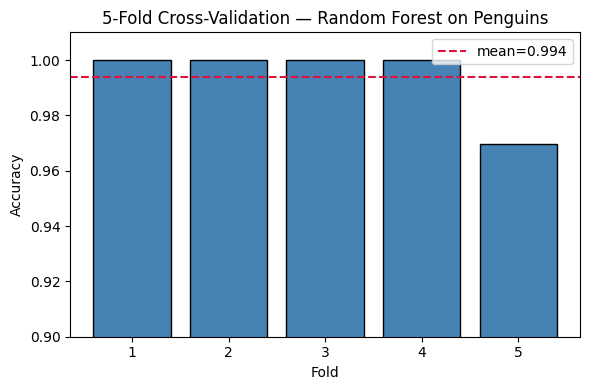

In [4]:
from sklearn.model_selection import cross_val_score

cv_acc = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
print("5-fold accuracy scores:", np.round(cv_acc, 3))
print(f"Mean: {cv_acc.mean():.3f}  Std: {cv_acc.std():.3f}")

plt.figure(figsize=(6, 4))
plt.bar(range(1, 6), cv_acc, color="steelblue", edgecolor="black")
plt.axhline(cv_acc.mean(), color="crimson", ls="--", label=f"mean={cv_acc.mean():.3f}")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation — Random Forest on Penguins")
plt.ylim(0.9, 1.01)
plt.legend()
plt.tight_layout()
plt.show()


---
## 6. Stratified K-Fold and Multiple Metrics

**StratifiedKFold** keeps class proportions similar in each fold — important for classification.

Track several metrics at once with `cross_validate` (returns dict of train/test scores per metric).


In [5]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
}

cv_results = cross_validate(pipe, X, y, cv=cv, scoring=scoring)

summary = pd.DataFrame({
    "metric": list(scoring.keys()),
    "mean": [cv_results[f"test_{k}"].mean() for k in scoring],
    "std": [cv_results[f"test_{k}"].std() for k in scoring],
}).round(3)

print("Cross-validation summary:\n", summary.to_string(index=False))


Cross-validation summary:
          metric  mean   std
       accuracy 0.994 0.007
precision_macro 0.993 0.009
   recall_macro 0.993 0.009
       f1_macro 0.993 0.009


---
## 7. Choosing the Right Metric for the Business Problem

| Business goal | Prefer | Why |
|---------------|--------|-----|
| Equal importance per species | **macro F1** | Rare species count as much as common |
| Overall correct rate (balanced data) | **accuracy** | Simple stakeholder message |
| Minimize false species ID in field study | **macro recall** | Don't miss a species |
| Costly follow-up on wrong ID | **macro precision** | Fewer wrong labels |

### Workflow recommendation

1. Check **class balance** (`value_counts`)
2. Pick **primary metric** with stakeholders
3. Use **stratified CV** on training pool
4. Hold out **test set once** at the end for final report

### Final hold-out test (Session 17 style)

After CV informs model choice, evaluate once on a held-out test split.


In [6]:
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print(f"Hold-out test accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nHold-out classification report (macro avg highlighted):\n")
print(classification_report(y_test, y_pred, digits=3))

# Compare single split vs CV mean
print(f"\nCV mean accuracy (5-fold): {cv_acc.mean():.3f}")
print("Lesson: CV mean and single test accuracy should be in the same ballpark.")


Hold-out test accuracy: 1.000

Hold-out classification report (macro avg highlighted):

              precision    recall  f1-score   support

      Adelie      1.000     1.000     1.000        29
   Chinstrap      1.000     1.000     1.000        14
      Gentoo      1.000     1.000     1.000        24

    accuracy                          1.000        67
   macro avg      1.000     1.000     1.000        67
weighted avg      1.000     1.000     1.000        67


CV mean accuracy (5-fold): 0.994
Lesson: CV mean and single test accuracy should be in the same ballpark.


---
## 🧪 Practice Exercises

1. On the **imbalanced toy data**, train a `RandomForestClassifier` instead of `DummyClassifier`. Report precision/recall for class 1.
2. For penguins, run `cross_val_score` with `cv=10`. How does std change vs `cv=5`?
3. Use `cross_validate` with `precision_weighted` and `precision_macro` — when do they differ most?
4. Artificially drop 80% of Chinstrap rows from penguins, retrain, and compare **accuracy** vs **macro F1**.
5. Plot fold-wise F1 (macro) as a bar chart for 5-fold CV.
6. Write a short memo: if the business cares most about **not mis-labeling Gentoo as Adelie**, which metric and matrix cell would you watch?
7. Why should you **not** use the test set inside a CV loop?
8. List three real-world problems where **recall** matters more than **precision**.

---

## 📝 Session 18 Summary

| Topic | Key takeaway |
|-------|--------------|
| **Accuracy limits** | Misleading when classes are imbalanced |
| **Precision / recall** | Reflect different costs of errors |
| **Averages** | macro vs weighted vs micro for multi-class |
| **Cross-validation** | More stable estimate than one split |
| **Pipelines in CV** | Preprocessing refits inside each fold |
| **StratifiedKFold** | Preserves class ratios per fold |
| **Metric choice** | Align with business cost of mistakes |

### Key gotchas
- **High accuracy** can mean nothing on skewed data
- **Tuning on test** or peeking at test repeatedly → optimistic bias
- **Macro** metrics can look low when one class is hard — investigate per-class report
- CV **std** matters — unstable models need more data or simpler models

### Next Session
**Session 19**: Hyperparameter Tuning and Model Selection — `GridSearchCV`, validation curves, and choosing models systematically.
